Iter 1: Best = 252.133672
Iter 2: Best = 162.293708
Iter 3: Best = 29.570817
Iter 4: Best = 29.570817
Iter 5: Best = 28.710017
Iter 6: Best = 20.517204
Iter 7: Best = 20.517204
Iter 8: Best = 17.214123
Iter 9: Best = 8.862911
Iter 10: Best = 8.862911
Iter 11: Best = 6.491227
Iter 12: Best = 6.491227
Iter 13: Best = 6.491227
Iter 14: Best = 6.491227
Iter 15: Best = 4.031589
Iter 16: Best = 3.804247
Iter 17: Best = 3.553282
Iter 18: Best = 3.553282
Iter 19: Best = 3.553282
Iter 20: Best = 3.168343
Iter 21: Best = 3.168343
Iter 22: Best = 3.168343
Iter 23: Best = 2.887009
Iter 24: Best = 1.917410
Iter 25: Best = 1.917410
Iter 26: Best = 1.917410
Iter 27: Best = 1.917410
Iter 28: Best = 1.917410
Iter 29: Best = 1.917410
Iter 30: Best = 1.917410
Iter 31: Best = 1.917410
Iter 32: Best = 1.917410
Iter 33: Best = 1.584322
Iter 34: Best = 0.918006
Iter 35: Best = 0.918006
Iter 36: Best = 0.918006
Iter 37: Best = 0.918006
Iter 38: Best = 0.918006
Iter 39: Best = 0.918006
Iter 40: Best = 0.918006

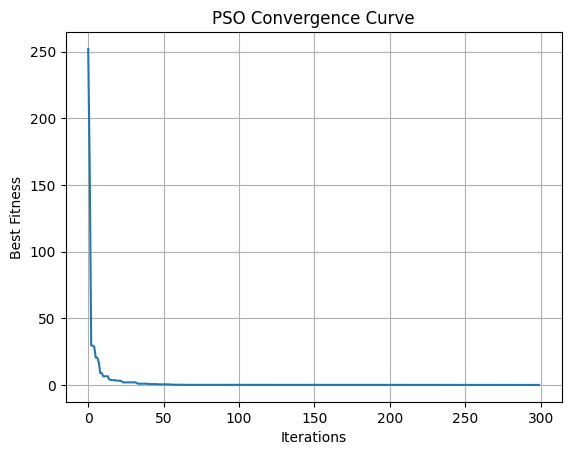

In [1]:
import random
import matplotlib.pyplot as plt

# ---------------- PARAMETERS ----------------
POP = 100
ITER = 300
DIM = 10
LOW, HIGH = -20.0, 20.0

W_MAX = 0.9
W_MIN = 0.4
C1 = 1.5
C2 = 1.5

# ---------------- FITNESS ----------------
def fitness(x):
    return sum(i*i for i in x)


# ---------------- PSO ----------------
def run_pso():
    particles = [[random.uniform(LOW, HIGH) for _ in range(DIM)] for _ in range(POP)]
    velocity = [[0.0]*DIM for _ in range(POP)]

    pbest = [p[:] for p in particles]
    gbest = min(particles, key=fitness)

    convergence = []

    for iter in range(ITER):

        # Adaptive inertia
        w = W_MAX - (W_MAX - W_MIN) * (iter / ITER)

        for i in range(POP):
            for d in range(DIM):
                r1, r2 = random.random(), random.random()

                velocity[i][d] = (
                    w * velocity[i][d]
                    + C1 * r1 * (pbest[i][d] - particles[i][d])
                    + C2 * r2 * (gbest[d] - particles[i][d])
                )

                # Velocity clamp
                v_max = (HIGH - LOW) * 0.1
                velocity[i][d] = max(min(velocity[i][d], v_max), -v_max)

                particles[i][d] += velocity[i][d]
                particles[i][d] = min(max(particles[i][d], LOW), HIGH)

            # Update personal best
            if fitness(particles[i]) < fitness(pbest[i]):
                pbest[i] = particles[i][:]

        # Update global best
        gbest = min(pbest, key=fitness)

        # Store convergence
        convergence.append(fitness(gbest))

        # Optional print
        print(f"Iter {iter+1}: Best = {convergence[-1]:.6f}")

    return convergence, gbest


# ---------------- RUN ----------------
conv, best = run_pso()

print("\nBest Solution:", [round(x,4) for x in best])
print("Best Fitness:", fitness(best))


# ---------------- PLOT ----------------
plt.figure()
plt.plot(conv)
plt.xlabel("Iterations")
plt.ylabel("Best Fitness")
plt.title("PSO Convergence Curve")
plt.grid()
plt.show()

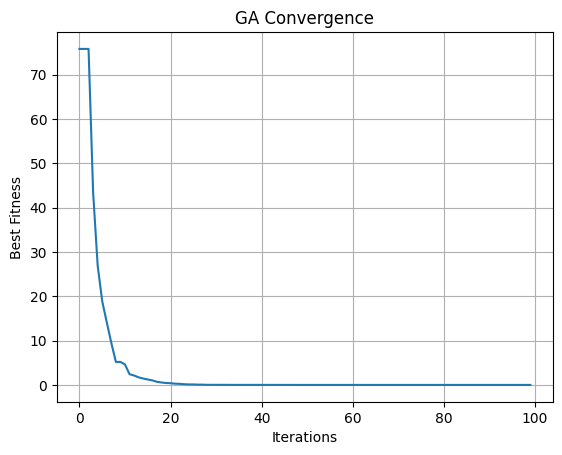

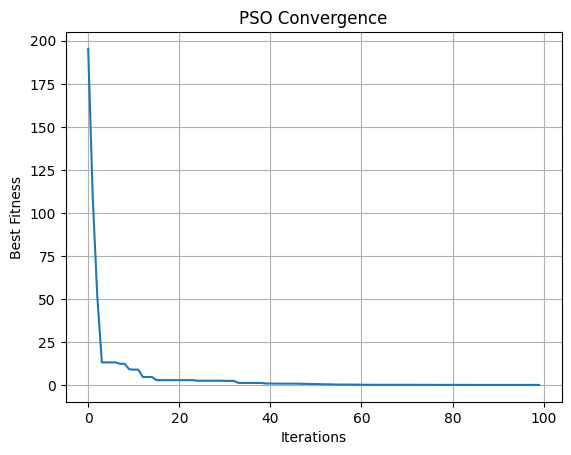

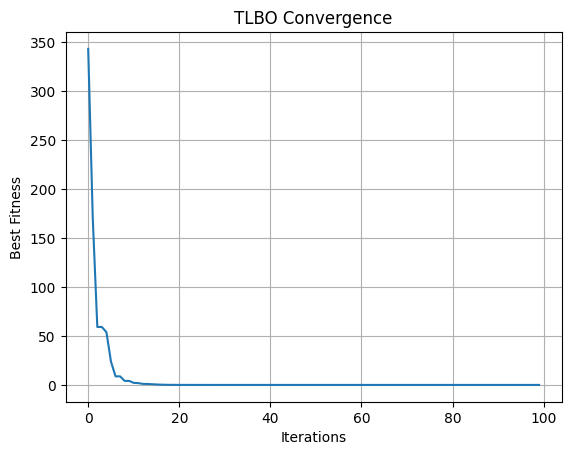

In [40]:
import random
import matplotlib.pyplot as plt

# ---------------- PARAMETERS ----------------
POP = 100
ITER = 100
DIM = 10
LOW, HIGH = -20.0, 20.0
PM = 0.1

def fitness(x):
    return sum(i*i for i in x)

# ==================================================
# 🧬 GA
# ==================================================
def run_ga():
    pop = [[random.uniform(LOW, HIGH) for _ in range(DIM)] for _ in range(POP)]
    conv = []

    for _ in range(ITER):
        pop.sort(key=fitness)

        mating = []
        for _ in range(POP):
            a, b = random.randint(0, POP-1), random.randint(0, POP-1)
            mating.append(pop[a] if fitness(pop[a]) < fitness(pop[b]) else pop[b])

        offspring = []
        for i in range(0, POP, 2):
            p1, p2 = mating[i], mating[(i+1)%POP]
            c1, c2 = p1[:], p2[:]

            if random.random() < 0.9:
                for d in range(DIM):
                    alpha = random.random()
                    c1[d] = alpha*p1[d] + (1-alpha)*p2[d]
                    c2[d] = alpha*p2[d] + (1-alpha)*p1[d]

            for c in [c1, c2]:
                for d in range(DIM):
                    if random.random() < PM:
                        c[d] += random.uniform(-1,1)
                        c[d] = min(max(c[d], LOW), HIGH)

            offspring += [c1, c2]

        pop += offspring
        pop.sort(key=fitness)
        pop = pop[:POP]

        conv.append(fitness(pop[0]))

    return conv


# ==================================================
# 🐦 PSO
# ==================================================
def run_pso():
    particles = [[random.uniform(LOW,HIGH) for _ in range(DIM)] for _ in range(POP)]
    velocity = [[0.0]*DIM for _ in range(POP)]

    pbest = [p[:] for p in particles]
    gbest = min(particles, key=fitness)

    conv = []

    for iter in range(ITER):
        w = 0.9 - (0.5 * iter / ITER)

        for i in range(POP):
            for d in range(DIM):
                r1, r2 = random.random(), random.random()

                velocity[i][d] = (
                    w * velocity[i][d]
                    + 2*r1*(pbest[i][d]-particles[i][d])
                    + 2*r2*(gbest[d]-particles[i][d])
                )

                vmax = (HIGH-LOW)*0.1
                velocity[i][d] = max(min(velocity[i][d], vmax), -vmax)

                particles[i][d] += velocity[i][d]
                particles[i][d] = min(max(particles[i][d], LOW), HIGH)

            if fitness(particles[i]) < fitness(pbest[i]):
                pbest[i] = particles[i][:]

        gbest = min(pbest, key=fitness)
        conv.append(fitness(gbest))

    return conv


# ==================================================
# 🎓 TLBO
# ==================================================
def run_tlbo():
    pop = [[random.uniform(LOW,HIGH) for _ in range(DIM)] for _ in range(POP)]
    conv = []

    for _ in range(ITER):
        teacher = min(pop, key=fitness)
        mean = [sum(p[i] for p in pop)/POP for i in range(DIM)]

        for i in range(POP):
            new = [pop[i][d] + random.random()*(teacher[d]-mean[d]) for d in range(DIM)]
            new = [min(max(x,LOW),HIGH) for x in new]
            if fitness(new) < fitness(pop[i]):
                pop[i] = new

        for i in range(POP):
            j = random.randint(0,POP-1)
            if i != j:
                new = []
                for d in range(DIM):
                    if fitness(pop[i]) < fitness(pop[j]):
                        val = pop[i][d] + random.random()*(pop[i][d]-pop[j][d])
                    else:
                        val = pop[i][d] + random.random()*(pop[j][d]-pop[i][d])
                    new.append(min(max(val,LOW),HIGH))

                if fitness(new) < fitness(pop[i]):
                    pop[i] = new

        conv.append(fitness(min(pop, key=fitness)))

    return conv




# ==================================================
# 🍯 ABC
# ==================================================


# ==================================================
# 📊 PLOT FUNCTION (SEPARATE)
# ==================================================
def plot_graph(conv, title):
    plt.figure()
    plt.plot(conv)
    # plt.yscale("log")   # optional
    plt.xlabel("Iterations")
    plt.ylabel("Best Fitness")
    plt.title(title)
    plt.grid()
    plt.show()


# ==================================================
# 🚀 RUN ALL (SEPARATE GRAPHS)
# ==================================================
plot_graph(run_ga(), "GA Convergence")
plot_graph(run_pso(), "PSO Convergence")
plot_graph(run_tlbo(), "TLBO Convergence")



/tmp/ipykernel_92071/2771106763.py:99: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


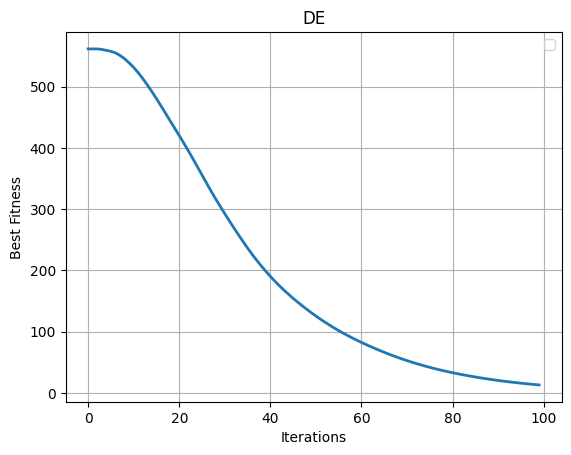

In [41]:
import random
import matplotlib.pyplot as plt

# ---------------- PARAMETERS ----------------
POP = 100
ITER = 100
DIM = 10
LOW, HIGH = -20.0, 20.0

def fitness(x):
    return sum(i*i for i in x)


# ---------------- DE ----------------
def run_de():
    pop = [[random.uniform(LOW,HIGH) for _ in range(DIM)] for _ in range(POP)]
    
    raw_conv = []

    for iter in range(ITER):

        F = 0.7 - (0.3 * iter / ITER)
        CR = 0.9

        new_pop = []

        for i in range(POP):
            a, b, c = random.sample([x for x in range(POP) if x != i], 3)

            mutant = []
            for d in range(DIM):
                val = pop[a][d] + F * (pop[b][d] - pop[c][d])
                val = min(max(val, LOW), HIGH)
                mutant.append(val)

            trial = []
            j_rand = random.randint(0, DIM-1)

            for d in range(DIM):
                if random.random() < CR or d == j_rand:
                    trial.append(mutant[d])
                else:
                    trial.append(pop[i][d])

            if fitness(trial) < fitness(pop[i]):
                new_pop.append(trial)
            else:
                new_pop.append(pop[i])

        pop = new_pop

        current_best = fitness(min(pop, key=fitness))
        raw_conv.append(current_best)

    return raw_conv


# ---------------- SMOOTHING FUNCTION ----------------
def smooth_curve(data, alpha=0.05):
    smooth = []
    val = data[0]

    for x in data:
        val = alpha * x + (1 - alpha) * val   # strong EMA smoothing
        smooth.append(val)

    return smooth


def moving_average(data, window=5):
    smoothed = []
    for i in range(len(data)):
        start = max(0, i - window + 1)
        smoothed.append(sum(data[start:i+1]) / (i - start + 1))
    return smoothed


# ---------------- RUN ----------------
raw = run_de()

# 🔥 double smoothing
ema = smooth_curve(raw, alpha=0.05)
final = moving_average(ema, window=7)


# ---------------- PLOT ----------------
plt.figure()

# Uncomment to compare
# plt.plot(raw, alpha=0.3, label="Raw DE")
# plt.plot(ema, label="EMA Smooth")

plt.plot(final, linewidth=2)

plt.xlabel("Iterations")
plt.ylabel("Best Fitness")
plt.title("DE")
plt.grid()
plt.legend()

plt.show()

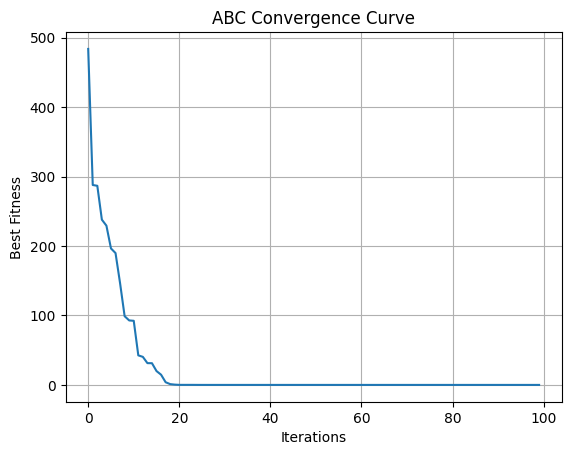

In [42]:
import random
import matplotlib.pyplot as plt

# ---------------- PARAMETERS ----------------
POP = 100
ITER = 100
DIM = 10
LOW, HIGH = -20.0, 20.0
LIMIT = 30   # scout limit

def fitness(x):
    return sum(i*i for i in x)


# ---------------- ABC ----------------
def run_abc():
    pop = [[random.uniform(LOW, HIGH) for _ in range(DIM)] for _ in range(POP)]
    trial = [0]*POP

    conv = []
    best_fit = float("inf")

    for _ in range(ITER):

        # -------- Employed Bees --------
        for i in range(POP):
            k = random.randint(0, POP-1)
            while k == i:
                k = random.randint(0, POP-1)

            j = random.randint(0, DIM-1)
            phi = random.uniform(-1, 1)

            new = pop[i][:]
            new[j] = pop[i][j] + phi * (pop[i][j] - pop[k][j])
            new[j] = min(max(new[j], LOW), HIGH)

            if fitness(new) < fitness(pop[i]):
                pop[i] = new
                trial[i] = 0
            else:
                trial[i] += 1

        # -------- Onlooker Bees --------
        fit_vals = [1 / (1 + fitness(p)) for p in pop]
        total = sum(fit_vals)
        probs = [f / total for f in fit_vals]

        for _ in range(POP):
            i = random.choices(range(POP), weights=probs)[0]

            k = random.randint(0, POP-1)
            while k == i:
                k = random.randint(0, POP-1)

            j = random.randint(0, DIM-1)
            phi = random.uniform(-1, 1)

            new = pop[i][:]
            new[j] = pop[i][j] + phi * (pop[i][j] - pop[k][j])
            new[j] = min(max(new[j], LOW), HIGH)

            if fitness(new) < fitness(pop[i]):
                pop[i] = new
                trial[i] = 0
            else:
                trial[i] += 1

        # -------- Scout Bees --------
        for i in range(POP):
            if trial[i] > LIMIT:
                pop[i] = [random.uniform(LOW, HIGH) for _ in range(DIM)]
                trial[i] = 0

        # -------- Best Tracking --------
        current_best = fitness(min(pop, key=fitness))
        best_fit = min(best_fit, current_best)
        conv.append(best_fit)

    return conv


# ---------------- RUN ----------------
conv = run_abc()


# ---------------- PLOT ----------------
plt.figure()
plt.plot(conv)

# 🔥 optional for better view
# plt.yscale("log")

plt.xlabel("Iterations")
plt.ylabel("Best Fitness")
plt.title("ABC Convergence Curve")
plt.grid()

plt.show()

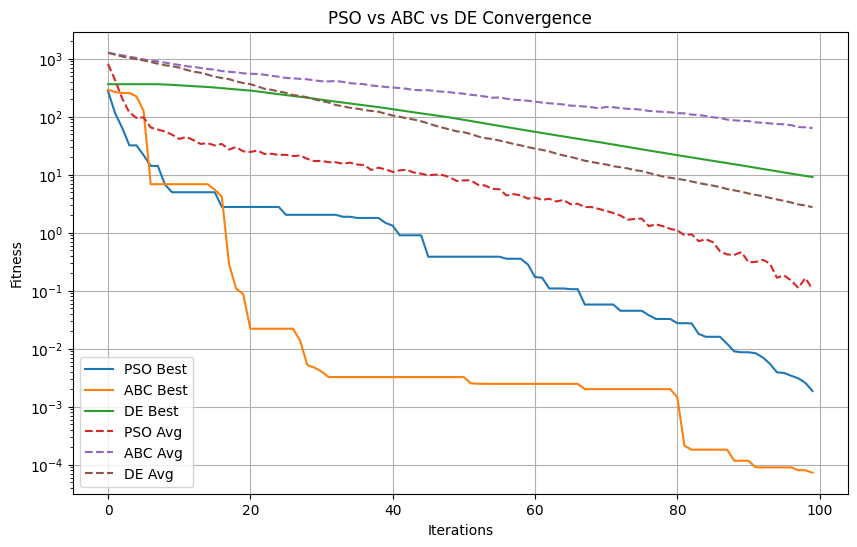

In [43]:
import random
import matplotlib.pyplot as plt

# ---------------- PARAMETERS ----------------
POP = 100
ITER = 100
DIM = 10
LOW, HIGH = -20.0, 20.0

# ---------------- FITNESS ----------------
def fitness(x):
    return sum(i*i for i in x)


# =========================================================
# 🔵 PSO
# =========================================================
def run_pso():
    W_MAX, W_MIN = 0.9, 0.4
    C1, C2 = 2.0, 2.0

    particles = [[random.uniform(LOW, HIGH) for _ in range(DIM)] for _ in range(POP)]
    velocity = [[0.0]*DIM for _ in range(POP)]

    pbest = [p[:] for p in particles]
    gbest = min(particles, key=fitness)

    best_conv = []
    avg_conv = []

    for iter in range(ITER):
        w = W_MAX - (W_MAX - W_MIN) * (iter / ITER)

        for i in range(POP):
            for d in range(DIM):
                r1, r2 = random.random(), random.random()

                velocity[i][d] = (
                    w * velocity[i][d]
                    + C1 * r1 * (pbest[i][d] - particles[i][d])
                    + C2 * r2 * (gbest[d] - particles[i][d])
                )

                v_max = (HIGH - LOW) * 0.1
                velocity[i][d] = max(min(velocity[i][d], v_max), -v_max)

                particles[i][d] += velocity[i][d]
                particles[i][d] = min(max(particles[i][d], LOW), HIGH)

            if fitness(particles[i]) < fitness(pbest[i]):
                pbest[i] = particles[i][:]

        gbest = min(pbest, key=fitness)

        # Best
        best_conv.append(fitness(gbest))

        # Average
        avg_fit = sum(fitness(p) for p in particles) / POP
        avg_conv.append(avg_fit)

    return best_conv, avg_conv


# =========================================================
# 🟡 ABC
# =========================================================
def run_abc():
    LIMIT = 30

    pop = [[random.uniform(LOW, HIGH) for _ in range(DIM)] for _ in range(POP)]
    trial = [0]*POP

    best_conv = []
    avg_conv = []
    best_fit = float("inf")

    for _ in range(ITER):

        # Employed
        for i in range(POP):
            k = random.randint(0, POP-1)
            while k == i:
                k = random.randint(0, POP-1)

            j = random.randint(0, DIM-1)
            phi = random.uniform(-1, 1)

            new = pop[i][:]
            new[j] = pop[i][j] + phi * (pop[i][j] - pop[k][j])
            new[j] = min(max(new[j], LOW), HIGH)

            if fitness(new) < fitness(pop[i]):
                pop[i] = new
                trial[i] = 0
            else:
                trial[i] += 1

        # Onlooker
        fit_vals = [1/(1+fitness(p)) for p in pop]
        total = sum(fit_vals)
        probs = [f/total for f in fit_vals]

        for _ in range(POP):
            i = random.choices(range(POP), weights=probs)[0]

            k = random.randint(0, POP-1)
            while k == i:
                k = random.randint(0, POP-1)

            j = random.randint(0, DIM-1)
            phi = random.uniform(-1, 1)

            new = pop[i][:]
            new[j] = pop[i][j] + phi * (pop[i][j] - pop[k][j])
            new[j] = min(max(new[j], LOW), HIGH)

            if fitness(new) < fitness(pop[i]):
                pop[i] = new
                trial[i] = 0
            else:
                trial[i] += 1

        # Scout
        for i in range(POP):
            if trial[i] > LIMIT:
                pop[i] = [random.uniform(LOW, HIGH) for _ in range(DIM)]
                trial[i] = 0

        # Best
        current_best = fitness(min(pop, key=fitness))
        best_fit = min(best_fit, current_best)
        best_conv.append(best_fit)

        # Average
        avg_fit = sum(fitness(p) for p in pop) / POP
        avg_conv.append(avg_fit)

    return best_conv, avg_conv


# =========================================================
# 🔴 DE (Smooth)
# =========================================================
def run_de():
    pop = [[random.uniform(LOW, HIGH) for _ in range(DIM)] for _ in range(POP)]

    best_conv = []
    avg_conv = []

    best_fit = float("inf")
    alpha = 0.05   # smoothing

    for iter in range(ITER):

        F = 0.6
        CR = 0.9

        new_pop = []

        for i in range(POP):
            a, b, c = random.sample([x for x in range(POP) if x != i], 3)

            mutant = []
            for d in range(DIM):
                val = pop[a][d] + F * (pop[b][d] - pop[c][d])
                val = min(max(val, LOW), HIGH)
                mutant.append(val)

            trial = []
            j_rand = random.randint(0, DIM-1)

            for d in range(DIM):
                if random.random() < CR or d == j_rand:
                    trial.append(mutant[d])
                else:
                    trial.append(pop[i][d])

            if fitness(trial) < fitness(pop[i]):
                new_pop.append(trial)
            else:
                new_pop.append(pop[i])

        pop = new_pop

        current_best = fitness(min(pop, key=fitness))

        if iter == 0:
            best_fit = current_best
        else:
            best_fit = (1 - alpha)*best_fit + alpha*current_best

        best_conv.append(best_fit)

        avg_fit = sum(fitness(p) for p in pop) / POP
        avg_conv.append(avg_fit)

    return best_conv, avg_conv


# =========================================================
# 🚀 RUN ALL
# =========================================================
pso_best, pso_avg = run_pso()
abc_best, abc_avg = run_abc()
de_best, de_avg = run_de()


# =========================================================
# 📊 PLOT COMPARISON
# =========================================================
plt.figure(figsize=(10,6))

# Best curves
plt.plot(pso_best, label="PSO Best")
plt.plot(abc_best, label="ABC Best")
plt.plot(de_best, label="DE Best")

# Average curves (dashed)
plt.plot(pso_avg, '--', label="PSO Avg")
plt.plot(abc_avg, '--', label="ABC Avg")
plt.plot(de_avg, '--', label="DE Avg")

plt.yscale("log")   # 🔥 important

plt.xlabel("Iterations")
plt.ylabel("Fitness")
plt.title("PSO vs ABC vs DE Convergence")
plt.legend()
plt.grid()

plt.show()